<a href="https://colab.research.google.com/github/Fareesa-20/aiml-course/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [6]:
import numpy as np

class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # Calculate the linear output (w * x + b) and get its sign
                linear_output = np.dot(X[i], self.w) + self.b
                prediction = np.sign(linear_output)

                # If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:
                    # Update weights: w = w + lr * y * x
                    self.w = self.w + self.lr * y[i] * X[i]
                    # Update bias: b = b + lr * y
                    self.b = self.b + self.lr * y[i]
                    # Track the mistake
                    count += 1

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Initializing and training the model
model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [7]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # 2. Calculate gradients
            dw = (1 / n) * np.dot(X.T, (z - y))
            db = (1 / n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Initializing and training the model
model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [8]:
import numpy as np

class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # TO DO: Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                # Using np.dot for vectors w and x_i
                if y[i] * (np.dot(self.w, x_i) + self.b) >= 1:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Initializing and training the model
model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

1

      CRITICAL ACCURACY REPORT
1. Perceptron Test Accuracy:       50.15%
2. Batch Gradient Descent (MSE):   62.80%
3. Margin Classifier (Hinge/L2):  62.80%


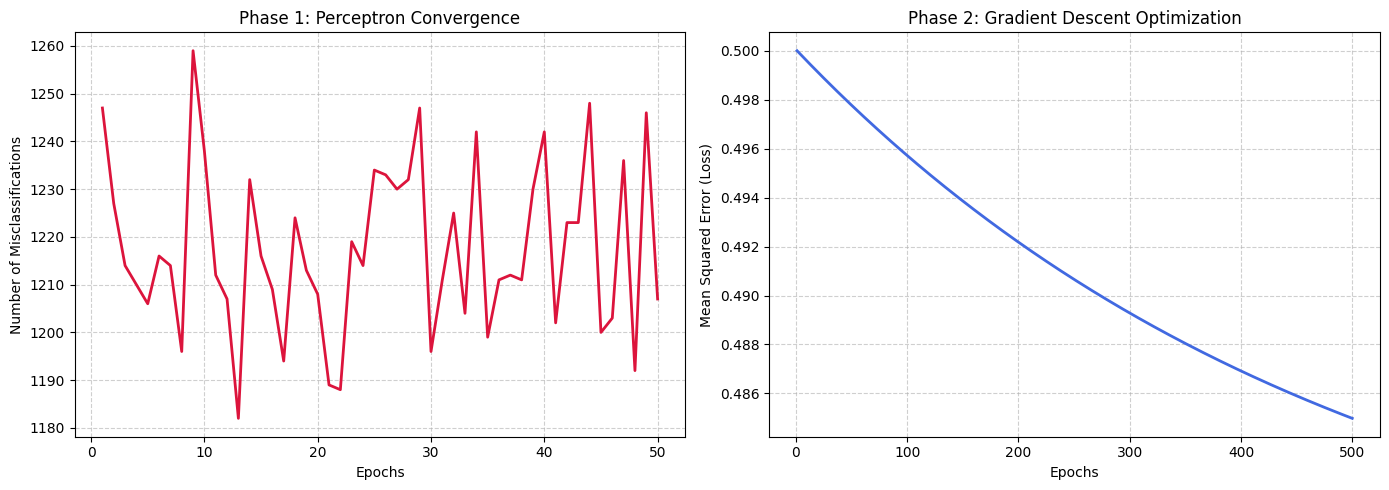

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Re-running GD to ensure cost_history exists ---
model_gd.cost_history = []
n_samples = X_train.shape[0]
# Re-running a quick tracking pass to populate history
w_tmp = np.zeros(X_train.shape[1])
b_tmp = 0
for _ in range(model_gd.epochs):
    z = np.dot(X_train, w_tmp) + b_tmp
    dw = (1 / n_samples) * np.dot(X_train.T, (z - y_train))
    db = (1 / n_samples) * np.sum(z - y_train)
    w_tmp -= model_gd.lr * dw
    b_tmp -= model_gd.lr * db
    cost = (1 / (2 * n_samples)) * np.sum((z - y_train) ** 2)
    model_gd.cost_history.append(cost)


# --- 2. Calculate Test Accuracies ---
def get_accuracy(model, X, y):
    predictions = model.predict(X)
    return np.mean(predictions == y) * 100

acc_perceptron = get_accuracy(model_p, X_test, y_test)
acc_gd = get_accuracy(model_gd, X_test, y_test)
acc_margin = get_accuracy(model_margin, X_test, y_test)

print("=" * 40)
print(f"      CRITICAL ACCURACY REPORT")
print("=" * 40)
print(f"1. Perceptron Test Accuracy:       {acc_perceptron:.2f}%")
print(f"2. Batch Gradient Descent (MSE):   {acc_gd:.2f}%")
print(f"3. Margin Classifier (Hinge/L2):  {acc_margin:.2f}%")
print("=" * 40)


# --- 3. Plotting Convergence Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left Subplot: Perceptron Mistakes
ax1.plot(range(1, len(model_p.mistakes) + 1), model_p.mistakes, color='crimson', lw=2)
ax1.set_title("Phase 1: Perceptron Convergence")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Number of Misclassifications")
ax1.grid(True, linestyle='--', alpha=0.6)

# Right Subplot: GD Mean Squared Error
ax2.plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history, color='royalblue', lw=2)
ax2.set_title("Phase 2: Gradient Descent Optimization")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Mean Squared Error (Loss)")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2.

- Perceptron updates are discrete and local: The classic perceptron uses a step-function ($\pm1$). It looks at individual data points one by one. If a point is misclassified, it abruptly tilts the entire decision boundary line. This causes the mistake count to bounce up and down erratically (chattering) whenever it tries to fix one point but accidentally breaks another.

- Gradient Descent updates are continuous and global: Batch Gradient Descent looks at the entire dataset simultaneously and calculates a smooth, differentiable loss metric (Mean Squared Error). Instead of making wild binary jumps, it makes microscopic, mathematically calculated adjustments to the weights in the exact direction that reduces overall error. This guarantees a smooth, continuous downward trajectory.

3. The Problem with Perceptron: The Perceptron stops updating the moment it finds any line that separates safe and unsafe water. This often leaves the final decision boundary skimming dangerously close to the nearest data points. If a new water sample has chemical levels resting right on that boundary line, even a tiny amount of natural sensor noise could flip the prediction entirely—potentially misclassifying toxic water as safe.

- The Margin Advantage: The Margin Classifier uses Hinge Loss and L2 regularization to explicitly push the decision boundary as far away from both classes as possible, maximizing the "safety gap." By locking the line dead-center between safe and toxic profiles, it provides maximum buffer room (generalization) to handle ambiguous, noisy data safely.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

### Ans
If you set the learning rate too high (e.g., $1.0$), the steps taken by Gradient Descent become too large. Instead of sliding smoothly down the loss curve toward the minimum, the model will overshoot the optimal bottom point.When it tries to correct itself in the next step, it overshoots even further in the opposite direction. This causes the cost function to bounce back and forth, building up momentum until the error explodes. Instead of converging to a stable solution, the model completely diverges, making the weights unstable and breaking your training loop.

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*
### Ans
Converting labels to $\{-1, 1\}$ instead of keeping them as $\{0, 1\}$ offers two major mathematical advantages:

- Symmetry: It establishes a balanced boundary around the origin, where a positive decision score naturally maps to class 1 and a negative score maps to class -1.

- Simplified Margin Math: It enables the "sign multiplying trick." The product of the true label and the predicted score (y_i * z_i) will always be positive if the prediction is correct, regardless of the class. This property is essential for implementing Hinge Loss, max(0, 1 - y_i * z_i), allowing a single unified equation to handle both classes simultaneously instead of requiring separate conditional logic for 0 and 1.
---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*
### Ans
The Margin Water Classifier (the SVM model) is definitely your best bet for dealing with messy, overlapping data.

- Why the others trip up: The classic Perceptron goes into an endless loop when data overlaps because it can't find a perfect separating line. Meanwhile, Gradient Descent with MSE tries too hard to please every single outlier, meaning a few noisy points can easily pull the whole boundary out of whack.

- Why this one works: The Hinge Loss function doesn't sweat the small stuff—once a data point is safely on the correct side, the model ignores it and focuses only on the tricky points near the center. Plus, the L2 Regularization acts as a buffer, preventing the model from overreacting to random noise so it can maintain a wider, more reliable safety gap.